# <span style="color:darkblue"> Assignment 4 </span>

# <span style="color:darkblue"> Zepeng Zhou </span>

## <span style="color:darkblue"> Import Libraries and Data  </span>

In [7]:
# import libraries
import multiprocess as mp
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# read data
bills_actions = pd.read_csv("/Users/zhouzepeng/Desktop/课程/# 25 fall/DATASCI-530_Computing1\
 /computing_25fall/Lecture 10/data_raw/bills_actions.csv")

## <span style="color:darkblue"> I. Despritive Statistics </span>

<font size = "4">

1) How many distinct “bill” identifiers are there? <br>
<br>
<font size = "2">
The number of distinct bill identifiers is 1331 <br>

In [16]:
# 1) Count the number of distinct bill identifiers
#    Each bill_number represents a unique legislative bill
num_distinct = bills_actions['bill_number'].nunique()
print(f"Number of distinct bill identifiers: {num_distinct}")

Number of distinct bill identifiers: 1331


<font size = "4">

2) What proportion of the rows belong to different categories? <br>
<br>

<font size = "2">

- In this step, I calculated how the dataset is distributed across different bill categories.<br>

- I used value_counts(normalize=True) on the category column to find the proportion of records<br>
 belonging to each category, and then converted these proportions into percentages for easier interpretation.<br>
- To visualize the results, I created a horizontal bar chart, where each bar represents one bill category <br>
and its length corresponds to its proportion of the total dataset.<br>
- Percentage labels were added to the end of each bar for clarity.<br>
<br>
Results：<br>
The dataset is dominated by amendments, which make up about 46% of all records.<br>
House bills account for roughly 27%, followed by senate bills at about 16%.<br>
Other categories such as house resolutions (7%) and senate resolutions (2%) are far less common.<br>
The remaining types—various forms of joint and concurrent resolutions—each represent less than 1% of the total.<br>

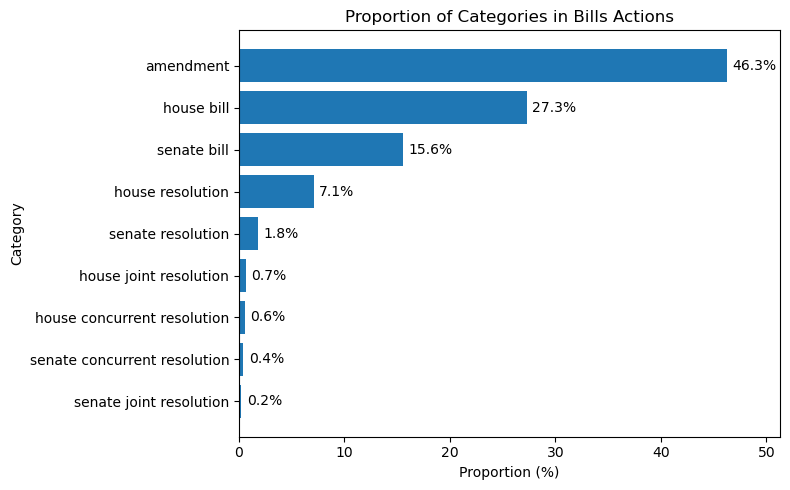

In [17]:
# 2) Calculate the proportion of rows belonging to each category
proportion_categories = (
    bills_actions['category']
    .value_counts(normalize=True)
    .sort_values(ascending=True)
)

## Convert proportions (0–1) to percentages (0–100)
prop_pct = proportion_categories * 100

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

## Draw a horizontal bar chart
# (default colors are kept for a clean, lecture-style look)
ax.barh(prop_pct.index, prop_pct.values)

## Add percentage labels to the end of each bar
for i, v in enumerate(prop_pct.values):
    ax.text(
        v + 0.5,                 # position slightly to the right of each bar
        i,                       # y-position corresponding to the bar
        f"{v:.1f}%",             # display percentage with one decimal place
        va="center"              # vertically center the text
    )

## Label axes and add a title
ax.set_xlabel("Proportion (%)")
ax.set_ylabel("Category")
ax.set_title("Proportion of Categories in Bills Actions")

## Extend x-axis a little so text labels are not cut off
ax.set_xlim(0, max(prop_pct.values) + 5)

plt.tight_layout()
plt.show()

<font size = "4">

3) Within each category, calculate the proportion of rows that belongs to different “main_action”.<br>
<br>
<font size = "2">

- In this step, I examined how different types of main actions are distributed within each bill category.<br>

- I grouped the data by category and main_action, and calculated the proportion of each action type <br>
within its category using value_counts(normalize=True).<br>

- The resulting cross-tab table shows categories as rows and main actions as columns, <br>
with the values representing proportions.<br>

- To visualize these proportions clearly, I plotted a stacked bar chart, <br>
where each bar represents one bill category and the colored segments <br>
represent the relative share of different main actions.<br>

<br>
Results:<br>
The distribution of main actions varies significantly across bill categories. <br>
For amendments, most actions involve house amendment offered and senate amendment proposed (on the floor). <br>
In house bills and senate bills, the dominant actions are committee/subcommittee actions and floor actions, <br>
reflecting the typical legislative process.<br>
For resolutions and joint/concurrent resolutions, floor actions are the most common, <br>
while other action types occur less frequently.<br>
<br>
Overall, the chart highlights clear institutional differences between House and Senate procedures,<br>
 as well as the distinct legislative paths taken by bills versus amendments.

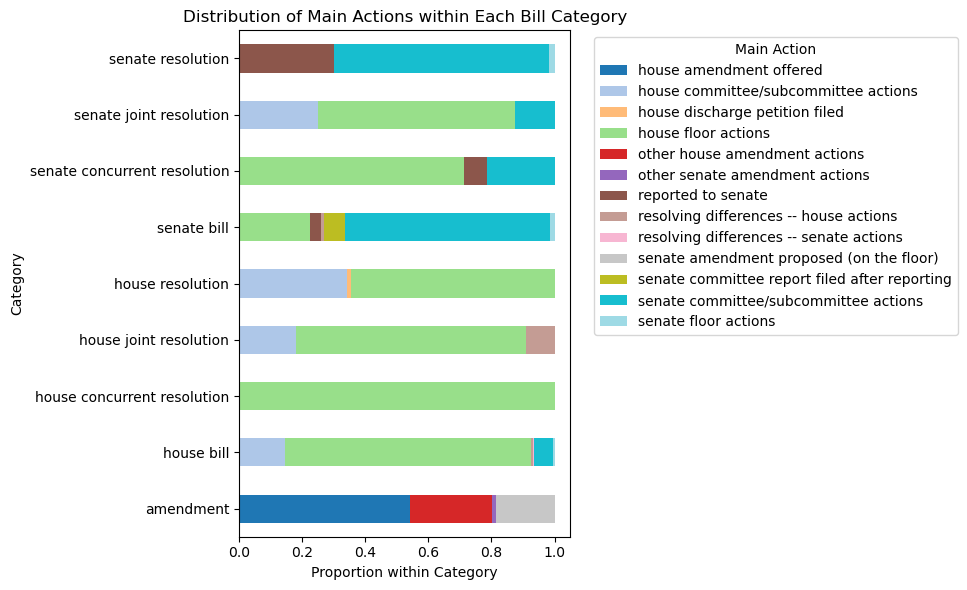

In [18]:
# 3) Within each category, calculate the proportion of rows 
#    that belong to different main_action types
#    The resulting table displays categories as rows and actions as columns

## Create a cross-tab (same as unstack but formatted better)
cat_action_prop = (
    bills_actions
    .groupby('category')['main_action']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

## Plot stacked bar chart
ax = cat_action_prop.plot(
    kind='barh', 
    stacked=True,
    figsize=(10, 6),
    colormap='tab20'  # colorful, readable
)

plt.xlabel("Proportion within Category")
plt.ylabel("Category")
plt.title("Distribution of Main Actions within Each Bill Category")
plt.legend(title="Main Action", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## <span style="color:darkblue"> II. House Floor Actions </span>

<font size = "4">

How many house floor actions are there as part of senate bills (category)?<br>
<br>
<font size = "2">
- In this step, I identified how many house floor actions were associated with senate bills.<br>
- I first created two logical filters: one to select rows where the category is “senate bill”, <br>
and another where the main action is “house floor actions.”
- By combining these two conditions, I created a subset of the dataset that includes only the actions meeting both criteria.<br>
- Finally, I counted the total number of rows in this subset to find how many house floor actions occurred as part of senate bills.<br>
<br>
Result:<br>
There're 116 house floor actions in senate bills. <br>




In [19]:
# Select rows where the category is "senate bill"
is_senate_bill = bills_actions['category'] == "senate bill"

# Select rows where the main_action is "house floor actions"
is_house_floor = bills_actions['main_action'] == "house floor actions"

# Create a subset that satisfies both conditions:
# actions that are part of senate bills and belong to house floor actions
subset_house_floor_in_senate = bills_actions[is_senate_bill & is_house_floor]

# Count the total number of these actions
n_house_floor_actions = len(subset_house_floor_in_senate)
print("Number of 'house floor actions' within 'senate bills':", n_house_floor_actions)

Number of 'house floor actions' within 'senate bills': 116


<font size = "4">
What proportion of these actions were suspended? <br>
What proportion of these actions were suspended as amended?<br>
<br>
<font size = "2">

- In this question, I focused only on the house floor actions that are part of senate bills.<br>
- First, I filtered the dataset to create a smaller subset containing only those rows.<br>
- Then, I checked how many of these actions mentioned the word “suspend”, <br>
and how many mentioned both “suspend” and “amended” in the action text.<br>
- I used simple text searching with str.contains() to find these keywords, ignoring letter case.<br>
- Finally, I calculated the proportion of these actions by dividing the number of matches <br>
by the total number of rows in the subset<br>
<br>
Results: <br>
- The proportion of "suspended" action is 68.97% <br>
- The proportion of "suspended as ammended" action is 15.52% 

In [20]:
# Count how many "house floor actions" mention the word "suspend"
is_suspended = subset_house_floor_in_senate['action'].str.contains("suspend", case=False, na=False)

# Count how many mention both "suspend" AND "amended"
is_suspended_amended = subset_house_floor_in_senate['action'].str.contains("suspend", case=False, na=False) & \
                       subset_house_floor_in_senate['action'].str.contains("amended", case=False, na=False)

# Calculate proportions relative to the total subset size
total_actions = len(subset_house_floor_in_senate)

prop_suspended = is_suspended.sum() / total_actions
prop_suspended_amended = is_suspended_amended.sum() / total_actions

# Print the results
print(f"Proportion of 'suspended' actions: {prop_suspended:.2%}")
print(f"Proportion of 'suspended as amended' actions: {prop_suspended_amended:.2%}")

Proportion of 'suspended' actions: 68.97%
Proportion of 'suspended as amended' actions: 15.52%


<font size = "4">

The house floor actions mention specific people mentioned by (Mr., Ms., Mrs., etc). <br>
Use regular expressions to extract the name of specific people. <br>
Produce a new dataset counting how many bills mention the same person and extracting <br>
the names of the people mentioned. <br>
What is the distribution of total bills proposed per person?<br>
<br>
<font size = "2">
- In this question, I focused on the house floor actions that are part of senate bills.<br>
- I used the .str.findall() method with a regular expression "(?:Mr|Ms|Mrs)\.?\s*\S+" <br>
to extract all occurrences of people’s names beginning with Mr., Ms., or Mrs.<br>
- Then, I expanded these matches using .explode() so that each name appears in its own row.<br>
- I counted how many times each person was mentioned to create a new dataset <br>
showing each person’s name and their number of mentions.<br>
- Finally, I calculated the distribution of total mentions per person and visualized it with a simple bar chart.<br>

<br>
Results<br>

- This result shows that most people were mentioned only once in the house floor actions.<br>
- A smaller number of individuals were mentioned two to five times, <br>
and only a few appeared many times — with the maximum being nine mentions. <br>
- Overall, the distribution is highly skewed, indicating that most names appear rarely, <br>
while only a few are repeatedly mentioned across multiple bills.


Total number of names extracted: 116


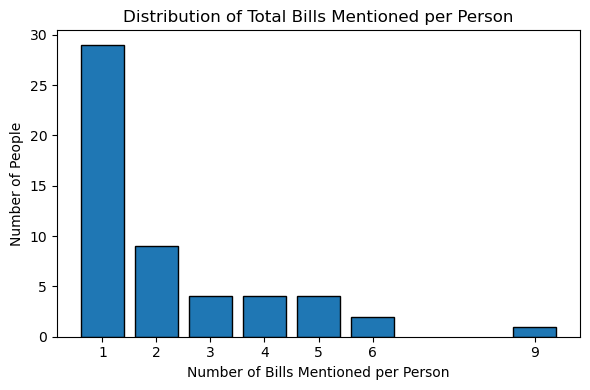

In [46]:
# Make a safe copy of the subset to avoid modifying the original DataFrame
subset_house_floor_in_senate = subset_house_floor_in_senate.copy()

# Use .str.findall() to extract all patterns that look like:
# "Mr Smith", "Ms. Johnson", "Mrs Brown", etc.
#   (?:Mr|Ms|Mrs) -  matches the honorifics "Mr", "Ms", or "Mrs"
#   \.?           -  optional period after the title (e.g., "Mr." or "Mr")
#   \s*           -  allows any number of spaces
#   \S+           -  matches one or more non-space characters (the last name)
subset_house_floor_in_senate["names_found"] = \
    subset_house_floor_in_senate["action"].str.findall("(?:Mr|Ms|Mrs)\\.\\s*\\S+")

# Explode the list of extracted names so that each name occupies its own row
# (e.g., if one action mentions 3 people, it becomes 3 separate rows)
names_exploded = subset_house_floor_in_senate.explode("names_found")

# Count how many total names were extracted (ignoring missing values)
total_names = names_exploded["names_found"].notna().sum()
print("Total number of names extracted:", total_names)

# Produce a new dataset counting how many bills mention the same person
name_counts = (
    names_exploded["names_found"]
    .value_counts()
    .reset_index()
)

# Visualization
## Calculate how many people were mentioned 1, 2, 3, ... times
dist = name_counts["count"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(dist.index, dist.values, edgecolor="black")

plt.xlabel("Number of Bills Mentioned per Person")
plt.ylabel("Number of People")
plt.title("Distribution of Total Bills Mentioned per Person")
plt.xticks(dist.index)   # 让横轴显示 1,2,3,4,5,6,9
plt.tight_layout()
plt.show()


## <span style="color:darkblue"> III. Senate Amendment Proposed </span>

<font size = "4">

Now focus a subset of bills whose actions are marked as “senate amendment proposed <br>
(on the floor)”. An important feature of the text is that it can mention one or more <br>
senators.<br>
1）Produce a new dataset counting how many senators are mentioned per bill. <br>
This dataset should also include two variables, with the name of the first senator <br>
(Senator 1) mentioned in the bill and the name of the second senator (Senator 2). <br>
What is the distribution of number of senators per bill?<br>
<br>
<font size = "2">

- In this question, I focused only on the bills where the main action was “senate amendment proposed (on the floor)”. <br>
- I used the .str.findall() method with the regular expression "Senator\s+\S+"  <br>
to extract all names beginning with “Senator” from the text of each bill. <br>
- Then, I counted how many senators were mentioned in each bill and saved this number as a new variable. <br>
- I also extracted the first and second senators mentioned (if any) into two separate columns,  <br>
Senator 1 and Senator 2, to prepare for later co-author analysis. <br>
Finally, I calculated the distribution of the number of senators mentioned per bill (typically one or two) <br>
 and visualized it with a bar chart showing how many bills had one or two senators. <br>

<br>
Results<br>

- Most bills mention two senators rather than just one.<br>
- Specifically, 196 bills include two senators, while 90 bills mention only one senator.<br>
- This suggests that Senate amendments proposed on the floor are often co-sponsored or co-authored by multiple senators.<br>


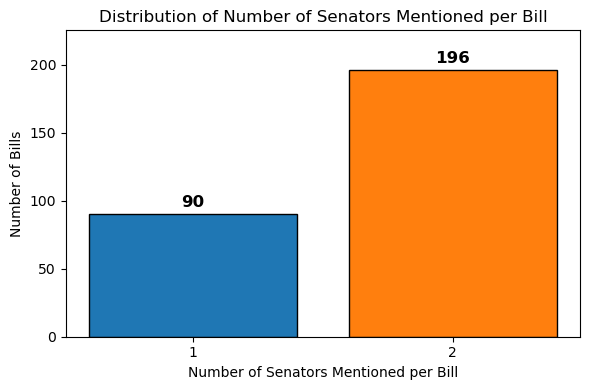

In [54]:
#-- Part 1 ---

# Focus on bills where a "senate amendment was proposed (on the floor)"
subset_senate_amendment = bills_actions[
    bills_actions["main_action"] == "senate amendment proposed (on the floor)"
].copy()

# Extract senator names mentioned in the 'action' column 
# The regular expression finds words starting with "Senator" followed by one or more non-space characters
subset_senate_amendment["senators_found"] = \
    subset_senate_amendment["action"].str.findall("Senator\\s+\\S+")

# Count how many senators are mentioned in each bill
subset_senate_amendment["num_senators"] = \
    subset_senate_amendment["senators_found"].apply(len)

# Extract the first and second senator mentioned (if available)
subset_senate_amendment["Senator_1"] = subset_senate_amendment["senators_found"].str[0]
subset_senate_amendment["Senator_2"] = subset_senate_amendment["senators_found"].str[1]

# Create a frequency distribution of number of senators per bill (e.g., 1 or 2)
dist = subset_senate_amendment["num_senators"].value_counts().sort_index()

# Visualization
plt.figure(figsize=(6,4))

## Two colors for the two bars (1 senator, 2 senators)
colors = ["#1f77b4", "#ff7f0e"]
bars = plt.bar(dist.index, dist.values, color=colors, edgecolor="black")

# Add count labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 3,  # 稍微高出柱子一点
        str(int(height)),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Add some extra vertical space so labels fit nicely
plt.ylim(0, dist.values.max() * 1.15)

plt.xlabel("Number of Senators Mentioned per Bill")
plt.ylabel("Number of Bills")
plt.title("Distribution of Number of Senators Mentioned per Bill")
plt.xticks([1, 2])
plt.tight_layout()
plt.show()


<font size = "4">
2）With how many different people does each Senator 1 coauthor bills, <br>
i.e. how many different people appear as Senator 2 for each Senator 1?<br>
<br>
<font size = "2">

- To study coauthorship, I kept only rows where both Senator 1 and Senator 2 exist<br>
-  then grouped by Senator 1 and counted the number of distinct Senator 2s (nunique) <br>
to get each Senator 1’s coauthor count.<br>
- Finally, I sorted senators by coauthor count (descending) <br>
and plotted a horizontal bar chart with value labels <br>
to show “how many different people appear as Senator 2 for each Senator 1.”<br>
<br>

Results<br>

- Senator McConnell stands out dramatically as the most frequent coauthor, <br>
collaborating with 75 different senators as “Senator 2.” <br>
- The second most active is Senator Reed, who coauthored bills with 25 different colleagues.<br>
- Most other senators have only a few coauthoring partners, typically between 1 and 9.


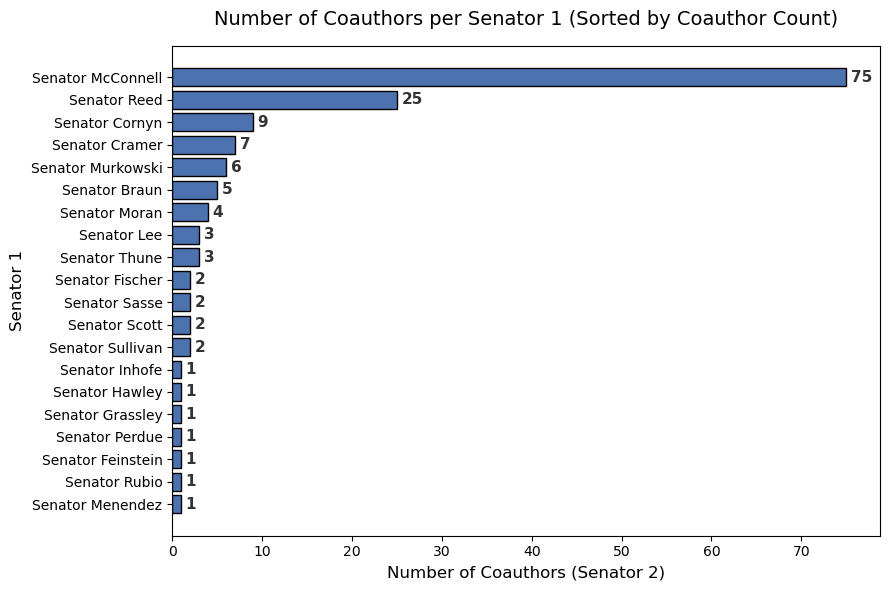

In [58]:
# Drop rows where either Senator_1 or Senator_2 is missing
coauthor_pairs = subset_senate_amendment.dropna(subset=["Senator_1", "Senator_2"])

# Count how many unique coauthors (Senator_2) each Senator_1 has
coauthor_counts = (
    coauthor_pairs.groupby("Senator_1")["Senator_2"]
    .nunique()
    .reset_index()
    .rename(columns={"Senator_2": "num_coauthors"})
    .sort_values("num_coauthors", ascending=False)   # 
)

# Visualization
plt.figure(figsize=(9, 6))
bars = plt.barh(
    coauthor_counts["Senator_1"],
    coauthor_counts["num_coauthors"],
    color="#4C72B0",  
    edgecolor="black"
)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,                      
        bar.get_y() + bar.get_height()/2, 
        f"{int(width)}",                  
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#333333"
    )

plt.xlabel("Number of Coauthors (Senator 2)", fontsize=12)
plt.ylabel("Senator 1", fontsize=12)
plt.title("Number of Coauthors per Senator 1 (Sorted by Coauthor Count)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()